![rmotr](https://user-images.githubusercontent.com/7065401/52071918-bda15380-2562-11e9-828c-7f95297e4a82.png)
<hr style="margin-bottom: 40px;">

<img src="https://user-images.githubusercontent.com/7065401/58563302-42466a80-8201-11e9-9948-b3e9f88a5662.jpg"
    style="width:400px; float: right; margin: 0 40px 40px 40px;"></img>

### Project

# Bike store sales

Let's put in practice the topics covered in the course and analyze sales made in a Bike Shop.

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)

## Hands on! 

In [34]:
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt

In [32]:
sales = pd.read_csv('data/sales_data.csv')

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### First look at our data

Analyze what columns we have, what type they are and what data is on them.

In [7]:
sales.shape
sales.index

RangeIndex(start=0, stop=5000, step=1)

In [5]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              5000 non-null   object
 1   Day               5000 non-null   int64 
 2   Month             5000 non-null   object
 3   Year              5000 non-null   int64 
 4   Customer_Age      5000 non-null   int64 
 5   Customer_Gender   5000 non-null   object
 6   Country           5000 non-null   object
 7   State             5000 non-null   object
 8   Product_Category  5000 non-null   object
 9   Sub_Category      5000 non-null   object
 10  Product           5000 non-null   object
 11  Order_Quantity    5000 non-null   int64 
 12  Unit_Cost         5000 non-null   int64 
 13  Unit_Price        5000 non-null   int64 
 14  Profit            5000 non-null   int64 
 15  Revenue           5000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 625.1+ KB


In [8]:
sales.head()

,Date,Day,Month,Year,Customer_Age,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Revenue
0,2014-03-05,5,March,2014,34,M,United States,California,Accessories,Fenders,Fender Set - Mountain,27,8,22,366,582
1,2013-08-18,18,August,2013,31,F,Canada,British Columbia,Clothing,Vests,"Classic Vest, L",13,24,64,512,824
2,2014-02-04,4,February,2014,31,F,United States,Washington,Bikes,Touring Bikes,"Touring-1000 Yellow, 54",1,1482,2384,378,1860
3,2013-09-09,9,September,2013,33,M,Australia,Victoria,Accessories,Tires and Tubes,LL Road Tire,25,8,21,215,415
4,2016-05-16,16,May,2016,35,F,United States,Washington,Accessories,Tires and Tubes,Mountain Tire Tube,28,2,5,53,109


In [9]:
sales.tail()

,Date,Day,Month,Year,Customer_Age,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Revenue
4995,2014-01-27,27,January,2014,34,M,United States,California,Accessories,Bottles and Cages,Water Bottle - 30 oz.,20,2,5,58,98
4996,2014-07-14,14,July,2014,17,M,France,Val d'Oise,Clothing,Caps,AWC Logo Cap,12,7,9,1,85
4997,2013-12-30,30,December,2013,25,F,Canada,British Columbia,Accessories,Helmets,"Sport-100 Helmet, Blue",20,13,35,433,693
4998,2016-01-06,6,January,2016,57,M,Canada,British Columbia,Accessories,Tires and Tubes,Patch Kit/8 Patches,16,1,2,16,32
4999,2014-03-09,9,March,2014,50,F,Australia,Queensland,Accessories,Tires and Tubes,Patch Kit/8 Patches,15,1,2,10,25


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Fixing column types

- Cast `Date` to `datetime`.
- Cast `Customer_Gender`, `Country`, `State`, `Product_Category` and `Sub_Category` to `category`.

In [20]:
# your code goes here
sales["Date"] = sales["Date"].astype("datetime64[ns]")
sales["Customer_Gender"] = sales["Customer_Gender"].astype("category")
sales["Country"] = sales["Country"].astype("category")
sales["State"] = sales["State"].astype("category")
sales["Product_Category"] = sales["Product_Category"].astype("category")
sales["Sub_Category"] = sales["Sub_Category"].astype("category")

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Get a summary of the main statistics of the whole data

In [21]:
# your code goes here
sales.describe()


,Date,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Revenue
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2014-11-24 09:47:13.920000,15.668800,2014.405000,35.933800,11.820400,278.415000,470.680600,291.653400,772.758000
min,2011-01-03 00:00:00,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-24.000000,2.000000
25%,2013-12-27 00:00:00,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,64.000000
50%,2014-07-02 12:00:00,16.000000,2014.000000,35.000000,10.000000,9.000000,25.000000,103.000000,226.000000
75%,2016-01-07 00:00:00,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,367.000000,829.250000
max,2016-07-31 00:00:00,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,5342.000000,14026.000000
std,NaN,8.797783,1.266055,11.087886,9.607841,562.721951,941.590529,457.359971,1306.052588


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### What's the mean of `Customers_Age`?

In [22]:
# your code goes here
sales["Customer_Age"].mean()


35.9338

Go ahead and show a <b>density (KDE)</b> and a <b>box plot</b> with the `Customer_Age` data:

<Axes: >

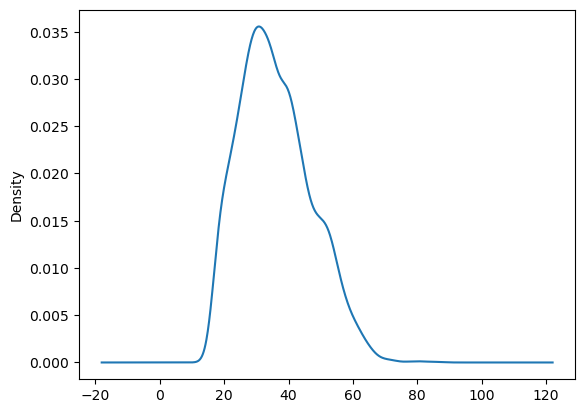

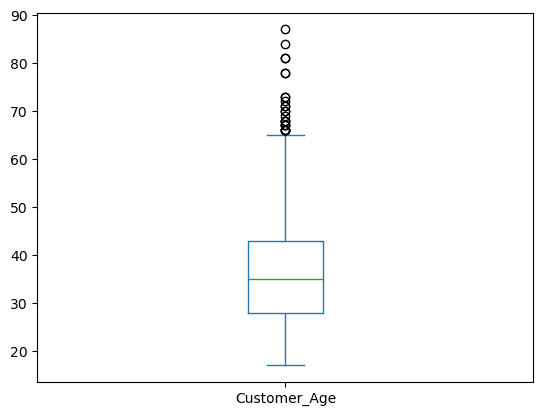

In [35]:
# your code goes here
sales["Customer_Age"].plot(kind="kde")
plt.figure()
sales["Customer_Age"].plot(kind="box")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### What's the mean of `Order_Quantity`?

In [36]:
# your code goes here
sales['Order_Quantity'].mean()

11.8204

Go ahead and show a <b>histogram</b> and a <b>box plot</b> with the `Order_Quantity` data:

<Axes: >

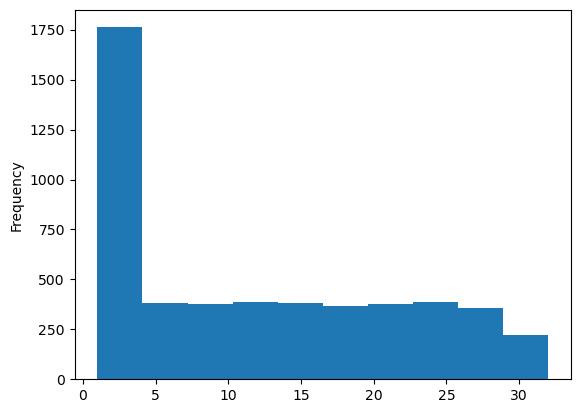

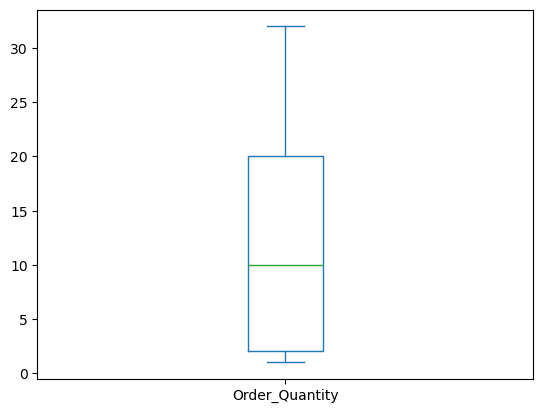

In [38]:
# your code goes here
sales["Order_Quantity"].plot(kind="hist")
plt.figure()
sales["Order_Quantity"].plot(kind = "box")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### In which countries were sales made?

In [40]:
# your code goes here
sales["Country"].unique()


array(['United States', 'Canada', 'Australia', 'United Kingdom',
       'Germany', 'France'], dtype=object)

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Sort sales by year

Older sales should be at the bottom.

In [42]:
# your code goes here
sales.sort_values(["Year"], inplace=True)


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Reset the current index

Don't keep the old index.

In [ ]:
# your code goes here
sales.reset_index(drop = True, inplace=True)


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many sales per year do we have?

In [45]:
# your code goes here
sales["Year"].value_counts()


Year
2014    1327
2016    1272
2015    1123
2013    1040
2011     126
2012     112
Name: count, dtype: int64

Go ahead and show a <b>pie plot</b> and a <b>bar plot</b> with the previous data:

<Axes: xlabel='Year'>

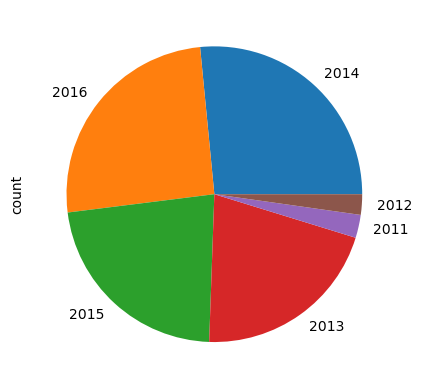

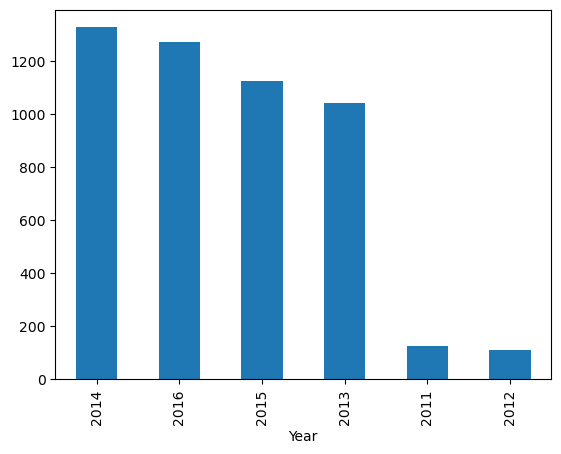

In [46]:
# your code goes here
sales["Year"].value_counts().plot(kind = "pie")
plt.figure()
sales["Year"].value_counts().plot(kind = "bar")

In [ ]:
# your code goes here


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Create a new `Cost` column

This column should be:
$$ Cost = Unit\_Cost * Order\_Quantity $$

In [47]:
# your code goes here
sales["Cost"] = sales["Unit_Cost"] * sales["Order_Quantity"]


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Create a new `YearMonth` column

This new `YearMonth` column should be the concatenation of `Year` and `Month` columns, separated by a '-'.

In [51]:
# your code goes here
sales["YearMonth"] = sales["Year"].astype("str") + "-" + sales["Month"].astype("str")

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How did sales evolve through the years?

Count how many sales we have per `YearMonth`.

In [52]:
# your code goes here
sales["YearMonth"].value_counts()


YearMonth
2015-December    232
2016-April       218
2013-December    215
2014-June        215
2016-May         214
                ... 
2012-December      7
2011-June          6
2011-February      6
2012-February      6
2012-March         4
Name: count, Length: 62, dtype: int64

Go ahead and show a <b>bar plot</b> with the previous data:

<Axes: xlabel='YearMonth'>

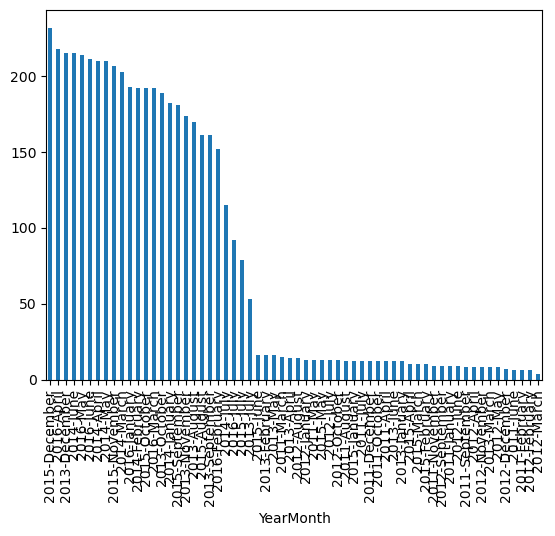

In [53]:
# your code goes here
sales["YearMonth"].value_counts().plot(kind = "bar")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Which country has the most sales `quantity of sales`?

In [56]:
# your code goes here
sales["Country"].max()
sales["Country"].value_counts()


Country
United States     1700
Australia         1066
Canada             657
United Kingdom     604
France             489
Germany            484
Name: count, dtype: int64

Go ahead and show a <b>bar plot</b> of the sales per country:

<Axes: xlabel='Country'>

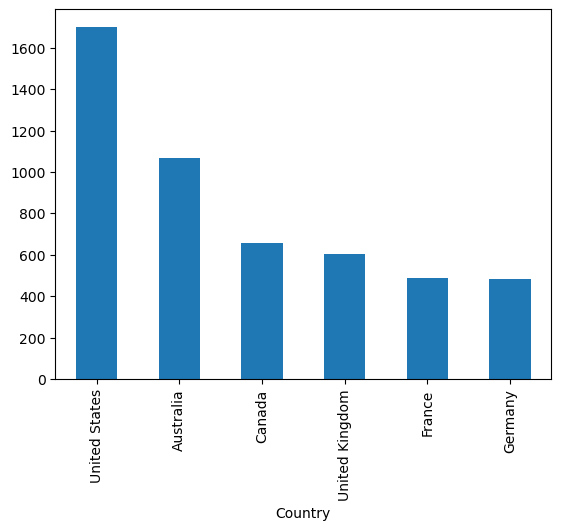

In [57]:
# your code goes here
sales["Country"].value_counts().plot(kind= "bar")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Get a list of every product sold

In [58]:
# your code goes here
sales["Product"].unique()


array(['Mountain-200 Silver, 42', 'Road-350-W Yellow, 42',
       'Road-150 Red, 48', 'Road-250 Red, 44', 'Mountain-200 Silver, 38',
       'Road-250 Red, 58', 'Road-250 Black, 44', 'Road-250 Black, 48',
       'Road-250 Black, 52', 'Road-750 Black, 44',
       'Mountain-200 Black, 38', 'Road-750 Black, 52',
       'Road-650 Black, 62', 'Mountain-400-W Silver, 38',
       'Road-550-W Yellow, 42', 'Road-350-W Yellow, 40',
       'Mountain-200 Black, 42', 'Road-550-W Yellow, 44',
       'Road-550-W Yellow, 38', 'Road-750 Black, 48', 'Road-650 Red, 52',
       'Road-250 Black, 58', 'Road-250 Red, 48', 'Road-650 Red, 62',
       'Road-550-W Yellow, 40', 'Road-750 Black, 58',
       'Road-650 Black, 58', 'Mountain-400-W Silver, 40',
       'Road-150 Red, 52', 'Road-350-W Yellow, 48',
       'Mountain-500 Black, 40', 'Road-150 Red, 56', 'Road-650 Red, 44',
       'Road-550-W Yellow, 48', 'Road-150 Red, 62',
       'Mountain-200 Silver, 46', 'Road-650 Red, 48',
       'Mountain-200 Black, 46'

Create a **bar plot** showing the 10 most sold products (best sellers):

<Axes: xlabel='Product'>

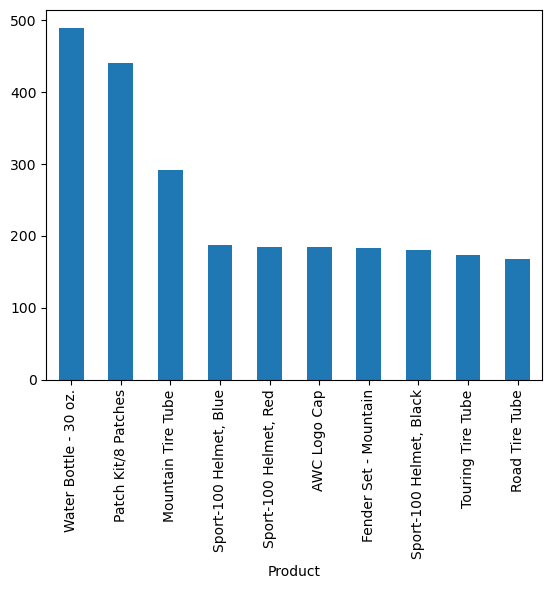

In [59]:
# your code goes here
sales["Product"].value_counts().head(10).plot(kind="bar")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Can you see any relationship between `Unit_Cost` and `Unit_Price`?

Show a <b>scatter plot</b> between both columns.

<Axes: xlabel='Unit_Cost', ylabel='Unit_Price'>

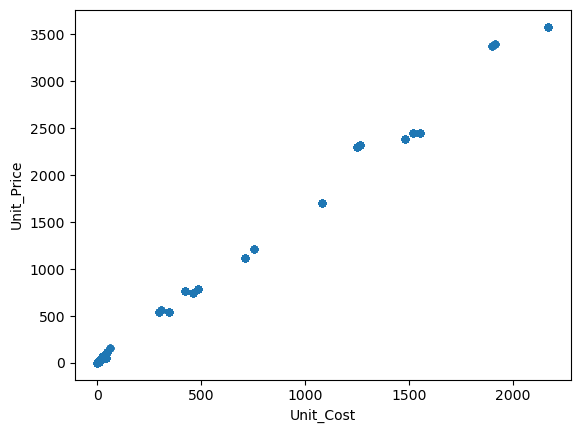

In [61]:
# your code goes here
sales[["Unit_Cost", "Unit_Price"]].plot(kind="scatter", x = "Unit_Cost", y = "Unit_Price")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Can you see any relationship between `Order_Quantity` and `Profit`?

Show a <b>scatter plot</b> between both columns.

<Axes: xlabel='Order_Quantity', ylabel='Profit'>

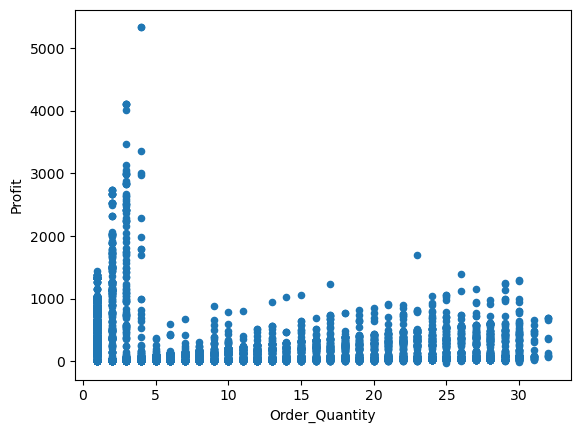

In [63]:
# your code goes here
sales.plot(kind="scatter", x = "Order_Quantity", y = "Profit")

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Can you see any relationship between `Profit` per `Country`?

Show a grouped <b>box plot</b> per country with the profit values.

Profit    Axes(0.125,0.11;0.775x0.77)
dtype: object

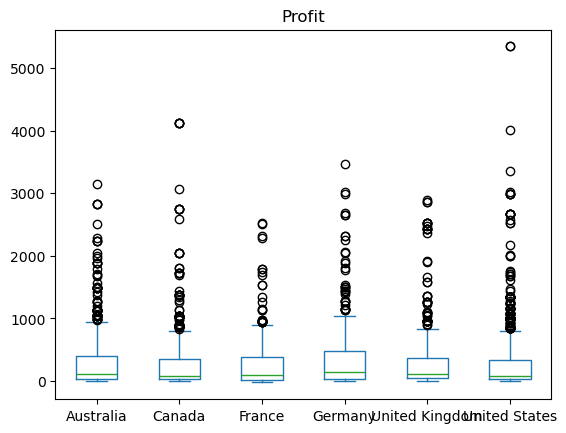

In [66]:
# your code goes here
sales[["Country", "Profit"]].plot(kind="box", by = 'Country')


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Can you see any relationship between the `Customer_Age` per `Country`?

Show a grouped <b>box plot</b> per country with the customer age values.

Customer_Age    Axes(0.125,0.11;0.775x0.77)
dtype: object

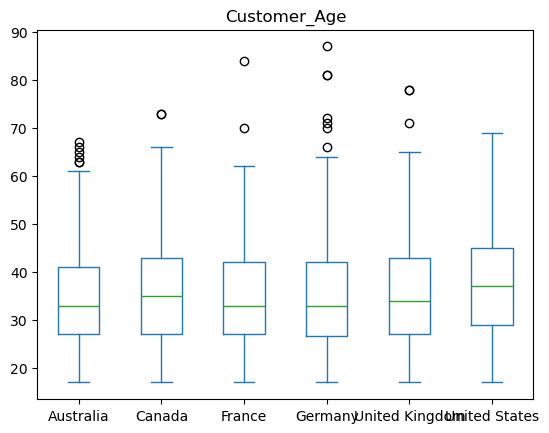

In [67]:
# your code goes here
sales[["Customer_Age", "Country"]].plot(kind="box", by = "Country")


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Increase 50 U$S revenue to every sale

In [68]:
# your code goes here
sales["Revenue"] += 50


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made in `Canada` or `France`?

In [129]:
# your code goes here
sales.loc[sales["Country"].isin(["Canada", "France"])].shape[0]
# sales["Sub_Category"].unique()

1146

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many `Bike Racks` orders were made from Canada?

In [ ]:
# your code goes here
sales.loc[(sales["Country"] == "Canada") & (sales["Sub_Category"] == "BikeRacks")].shape[0]


0

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made in each region (state) of France?

In [91]:
# your code goes here
sales.loc[(sales["Country"] == "France"), ["State"]].value_counts()


State            
Seine (Paris)        101
Seine Saint Denis     87
Nord                  76
Yveline               48
Hauts de Seine        41
Essonne               40
Moselle               16
Seine et Marne        16
Loiret                13
Val d'Oise            11
Charente-Maritime     10
Garonne (Haute)       10
Pas de Calais          6
Loir et Cher           5
Val de Marne           5
Somme                  4
Name: count, dtype: int64

Go ahead and show a <b>bar plot</b> with the results:

<Axes: xlabel='State'>

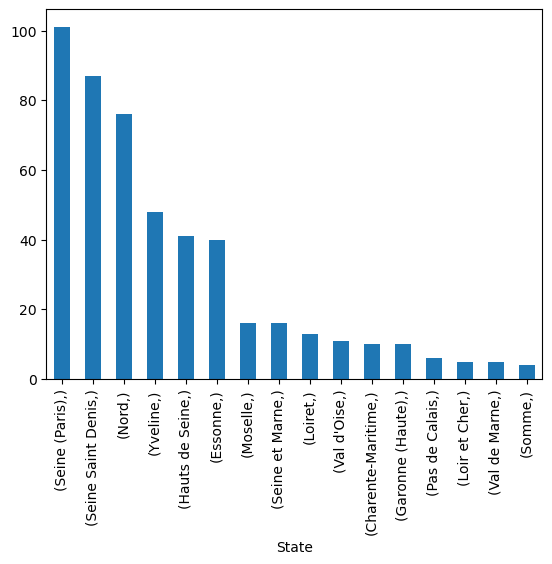

In [92]:
# your code goes here
sales.loc[(sales["Country"] == "France"), ["State"]].value_counts().plot(kind="bar")

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many sales were made per category?

In [94]:
# your code goes here
sales["Product_Category"].value_counts()


Product_Category
Accessories    3090
Bikes          1166
Clothing        744
Name: count, dtype: int64

Go ahead and show a <b>pie plot</b> with the results:

<Axes: ylabel='count'>

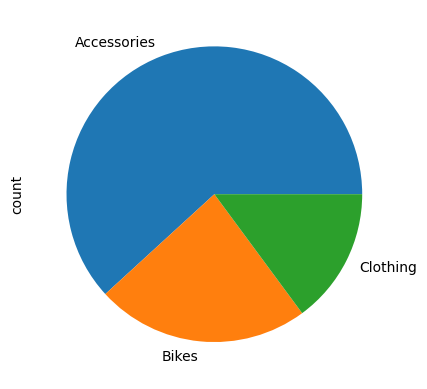

In [95]:
# your code goes here

sales["Product_Category"].value_counts().plot(kind="pie")

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made per accessory sub-categories?

In [97]:
# your code goes here
sales.loc[sales["Product_Category"] == "Accessories", "Sub_Category"].value_counts()


Sub_Category
Tires and Tubes      1458
Bottles and Cages     719
Helmets               553
Fenders               183
Cleaners               78
Hydration Packs        64
Bike Racks             26
Bike Stands             9
Name: count, dtype: int64

Go ahead and show a <b>bar plot</b> with the results:

In [ ]:
# your code goes here


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made per bike sub-categories?

In [99]:
# your code goes here
sales.loc[sales["Product_Category"] == "Bike", "Sub_Category"].value_counts()


Series([], Name: count, dtype: int64)

Go ahead and show a <b>pie plot</b> with the results:

In [ ]:
# your code goes here


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Which gender has the most amount of sales?

In [101]:
# your code goes here
sales["Customer_Gender"].value_counts().sort_values(ascending=False)


Customer_Gender
M    2564
F    2436
Name: count, dtype: int64

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many sales with more than 500 in `Revenue` were made by men?

In [108]:
# your code goes here
sales.loc[(sales["Revenue"] > 500) & (sales["Customer_Gender"] == "M")].shape[0]


1058

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Get the top-5 sales with the highest revenue

In [109]:
# your code goes here
sales.sort_values(["Revenue"], ascending=False).head(5)


,index,Date,Day,Month,Year,Customer_Age,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Revenue,Cost,YearMonth
112,2686,2011-03-27,27,March,2011,24,M,United States,California,Bikes,Road Bikes,"Road-150 Red, 44",4,2171,3578,5342,14076,8684,2011-March
97,743,2011-01-17,17,January,2011,44,F,United States,California,Bikes,Road Bikes,"Road-150 Red, 62",4,2171,3578,5342,14076,8684,2011-January
4295,2826,2016-01-09,9,January,2016,40,F,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 52",3,2171,3578,4114,10677,6513,2016-January
2722,3530,2015-12-11,11,December,2015,44,M,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 62",3,2171,3578,4114,10677,6513,2015-December
96,1490,2011-12-29,29,December,2011,25,M,Canada,British Columbia,Bikes,Road Bikes,"Road-150 Red, 62",3,2171,3578,4114,10677,6513,2011-December


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Get the sale with the highest revenue

In [116]:
# your code goes here
sales.loc[sales['Revenue'] == sales['Revenue'].max()]


,index,Date,Day,Month,Year,Customer_Age,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Revenue,Cost,YearMonth
97,743,2011-01-17,17,January,2011,44,F,United States,California,Bikes,Road Bikes,"Road-150 Red, 62",4,2171,3578,5342,14076,8684,2011-January
112,2686,2011-03-27,27,March,2011,24,M,United States,California,Bikes,Road Bikes,"Road-150 Red, 44",4,2171,3578,5342,14076,8684,2011-March


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### What is the mean `Order_Quantity` of orders with more than 10K in revenue?

In [118]:
# your code goes here
sales.loc[sales['Revenue'] > 10000, "Order_Quantity"].mean()


3.25

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### What is the mean `Order_Quantity` of orders with less than 10K in revenue?

In [120]:
# your code goes here
sales.loc[~(sales['Revenue'] > 10000), "Order_Quantity"].mean()

11.834134615384615

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made in May of 2016?

In [122]:
# your code goes here
sales.loc[(sales["Month"] == "May") & (sales["Year"] == 2016)].value_counts().shape[0]


214

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### How many orders were made between May and July of 2016?

In [124]:
# your code goes here
cond = (sales['Year'] == 2016) & (sales['Month'].isin(['May', 'June', 'July']))

sales.loc[cond].shape[0]

517

Show a grouped <b>box plot</b> per month with the profit values.

<Axes: title={'center': 'Profit'}, xlabel='[Month]'>

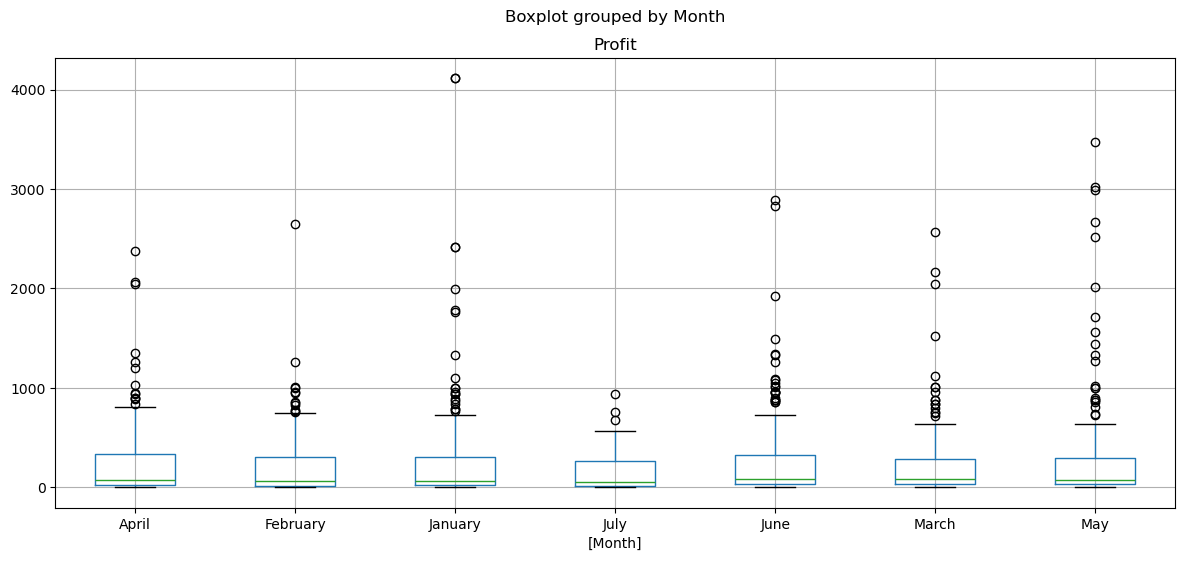

In [125]:
# your code goes here
profit_2016 = sales.loc[sales['Year'] == 2016, ['Profit', 'Month']]

profit_2016.boxplot(by='Month', figsize=(14,6))

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

### Add 7.2% TAX on every sale `Unit_Price` within United States

In [127]:
# your code goes here
sales.loc[sales['Country'] == 'United States', 'Unit_Price'] *= 1.072

![purple-divider](https://user-images.githubusercontent.com/7065401/52071927-c1cd7100-2562-11e9-908a-dde91ba14e59.png)